# Pure Streaming Example:  A Simple Moving Average Filter

To illustrate the AXI4-Streaming protocol we consider implementing a simple moving average of the square of an input:

```python 
y[n] = 1/(win_size)*( x[n]**2 + ... + x[n-win_size+1]**2 )
```

where `x[n]` is a stream of inputs and `y[n]` is the moving average window of the 
This operation can be considered an example of **pure streaming** since there is a one input `x[n]` for each output `y[n]`.  The kernel can operate continuously without any explicit start and stop.  

## Vitis HLS implementation

The main function implementing the streaming is in `avgfilt.cpp`.  The kernel declaration is:

```c
void avgfilt(
    hls::stream<float>& in_stream, 
    hls::stream<float>& out_stream)
{

#pragma HLS INTERFACE axis port=in_stream
#pragma HLS INTERFACE axis port=out_stream
#pragma HLS INTERFACE ap_ctrl_none port=return

...
}
```

The function defines an input stream `in_stream` and output stream `out_stream`.  The main loop is:

```c
    while (1) {
 
#pragma HLS PIPELINE II=1
        // Read value
        float xi = in_stream.read();
        float xsq = xi*xi;

        // Output value
        float yi = (xsq + xsq0 + xsq1)*inv_win_size;
        out_stream.write(yi);

        // Update delay line
        xsq1 = xsq0;
        xsq0 = xsq;
    }
```

In each cycle, the kernel reads an input `xi` from the input stream, squares it, computes the average from the previous values and updates a delay line.  The output is written to an output stream.

There is also a testbench, `tb_avgfilt.cpp` that sends some data to the kernel and compares the returned results with expected values.




## Running C  and RTL simulation

You can compile the averaging kernel and testbench from a command terminal with the command:

```bash
vitis-run --mode hls --tcl run_hls_avg.tcl
```

Running the file will:

- Perform a C simulation.  
- Synthesis of the kernel to RTL
- RTL simulation

## Viewing the Timing Diagram

The Vitis RTL simulation does not generally produce a timing waveform that can be easily read into python.  So, we re-run the simulation with the following command to capture a VCD file.  

```bash
xsim_vcd --top poly --comp hls_component --out dump_avg.vcd
```

You can run this command at the command window.   Running the command will re-run the RTL simulation to generate a VCD file.  The VCD file will be placed in `vcd\dum_avg.vcd`.  

You can then load the file as follows:

In [1]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

# Check if VCD file exists
vcd_file = 'dump_avg.vcd'
import os
fn = os.path.join(os.getcwd(), 'vcd', vcd_file)
if not os.path.exists(fn):
    raise FileNotFoundError(f"VCD file not found: {fn}")

# Parse the VCD file
vcd = VCDVCD(fn, signals=None, store_tvs=True)

We can print the signals available as follows:

In [2]:
nsig = len(vcd.signals)
print(f"Number of signals in VCD: {nsig}")

# Find the signals with TDATA and TREADY in their names
tdatas = [s for s in vcd.signals if 'TDATA' in s]
print(tdatas)

Number of signals in VCD: 348
['apatb_avgfilt_top.in_stream_TDATA[31:0]', 'apatb_avgfilt_top.out_stream_TDATA[31:0]', 'apatb_avgfilt_top.AESL_inst_avgfilt.in_stream_TDATA[31:0]', 'apatb_avgfilt_top.AESL_inst_avgfilt.out_stream_TDATA[31:0]', 'apatb_avgfilt_top.AESL_inst_avgfilt.in_stream_TDATA_blk_n', 'apatb_avgfilt_top.AESL_inst_avgfilt.out_stream_TDATA_blk_n', 'apatb_avgfilt_top.AESL_inst_avgfilt.in_stream_TDATA_int_regslice[31:0]', 'apatb_avgfilt_top.AESL_inst_avgfilt.out_stream_TDATA_int_regslice[31:0]']


We now load utilities from the PySilicon package for viewing the VCD files

In [3]:

from pysilicon.utils.vcd import VcdParser
from pysilicon.utils.timing import TimingDiagram

We then extract the signals for the input and output streams.

In [5]:
# Create a parsing class
vp = VcdParser(vcd)

# Get the clock signal name
clk_name = vp.add_clock_signal()
top_name = 'apatb_avgfilt_top'
in_stream_name = f"{top_name}.in_stream_"
out_stream_name = f"{top_name}.out_stream_"
    
# Get the  AXI-Stream command signals
in_str_sigs, in_bw = vp.add_axiss_signals(name=in_stream_name, short_name_prefix='in_stream',
                                           ignore_multiple=True)
print(in_str_sigs)

# Get the output AXI-Stream signals
out_str_sigs, out_bw = vp.add_axiss_signals(name=out_stream_name, short_name_prefix='out_stream',
                                            ignore_multiple=True)
print(out_str_sigs)




{'tdata': 'apatb_avgfilt_top.in_stream_TDATA[31:0]', 'tvalid': 'apatb_avgfilt_top.in_stream_TVALID', 'tready': 'apatb_avgfilt_top.in_stream_TREADY', 'tlast': None}
{'tdata': 'apatb_avgfilt_top.out_stream_TDATA[31:0]', 'tvalid': 'apatb_avgfilt_top.out_stream_TVALID', 'tready': 'apatb_avgfilt_top.out_stream_TREADY', 'tlast': None}


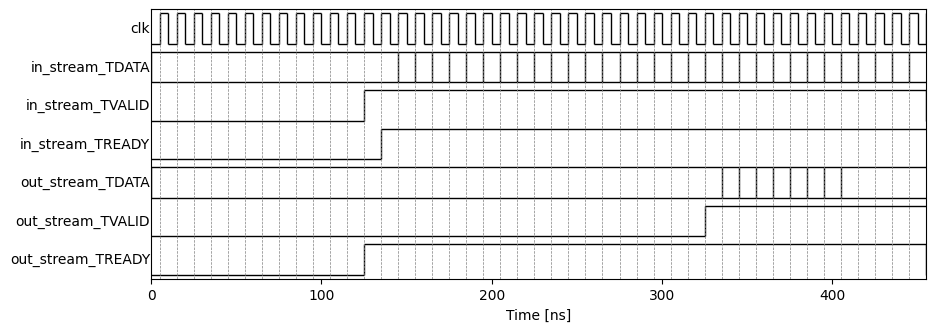

In [6]:
# Get the timing signals
sig_list = vp.get_td_signals()

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')